# Web pages as screenshots

> A pilot on Multimodal-Mind2Web: 467 browser steps with the page's screenshot, and two questions. Does NeoMME-260M or ModernVBERT read them better, and does the screenshot help at all over the page's text?

- skip_exec: true
- skip_showdoc: true

sysone's multimodal application exists for decisions over screens: a browser agent looking at a page and choosing what to do next. Its default encoder was NeoMME-260M, which H company built for screenshots and documents. On the only real images tested so far, small ones, ModernVBERT won by a wide margin: 0.84 against 0.31 on a digit choice and 0.94 against 0.74 on photos. But the [comparison tutorial](03_neomme_vs_modernvbert.ipynb) pointed out that tiny digits and stock photos favour an image tower trained on natural photos, and that pages are the test that decides between the two. This notebook runs that test, at pilot scale.

The data is [Multimodal-Mind2Web](https://huggingface.co/datasets/osunlp/Multimodal-Mind2Web) (OpenRAIL): one row per recorded browser action, with a screenshot of the page and the elements a person could have acted on. sysone's [screens](../21_screens.ipynb) converter turns each action into two questions:

- **`operation`**: which kind of action comes next, among the page's operations (click, type, select) and the controls (wait, scroll, done, blocked);
- **the target**: which element to act on, among the right one and up to 44 others from the page.

Five heads answer them, each on a frozen encoder: NeoMME-260M and ModernVBERT with the screenshot, the same two without it, and ModernBERT-large, the text application's default, without it. The text-only runs answer the question under the question: if the page's text alone does as well, the screenshot isn't worth its cost. The [text tutorial](06_web_text.ipynb) compares the same encoders, and GLiNER2.5-Decide, on 3,000 more steps in text alone.

This is a pilot: 276 training steps from 30 websites, and 191 test steps from 9 websites none of them saw. Differences of a few points between runs are within the noise. What it can show is the direction, the cost of each encoder on real pages, and what a full run would need.

::: {.callout-tip title="Jargon"}
- **Parquet, row group, column**: Multimodal-Mind2Web is stored as Parquet files, which keep each column of a block of rows (a *row group*) together. A reader can fetch one block and only the columns it needs, over HTTP, without downloading the file.
- **Crop**: cutting a region out of an image. Here, the top of a page that can be 20,000 pixels tall.
- **Patch, tile**: NeoMME cuts an image into 32-pixel patches, one token each. ModernVBERT cuts it into 512-pixel tiles, and its vision tower turns each tile into 64 tokens, plus 64 for a small copy of the whole image.
- **Operation, target**: the two questions of a step, what kind of action and on which element.
- **Held-out websites**: websites none of whose steps were used for training.
:::

::: {.callout-note title="Running this notebook"}
The test suite skips this notebook (`skip_exec`). The first run streams about 0.5 GB of Multimodal-Mind2Web and saves the 467 steps and their screenshots in `web-screens/`, next to the notebook; later runs read them from there. It uses NeoMME-260M (526 MB), ModernVBERT (1.2 GB) and ModernBERT-large (1.6 GB), one at a time. The whole run takes about 32 minutes on an M3 Pro (MPS, fp32), and the outputs below come from a run on 2026-09-30. Multimodal-Mind2Web's licence (OpenRAIL) restricts what may be done with derived data, so this notebook shows no screenshot: it describes them.
:::

In [ ]:
import gc, json, random, resource, sys, time, logging, warnings
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import pyarrow.parquet as pq
import datasets, transformers
from huggingface_hub import HfFileSystem
from PIL import Image as PILImage
from transformers.trainer_callback import PrinterCallback, ProgressCallback
from sysone.data import TypedDecisions
from sysone.datasets import mm_mind2web_record, MM_COLUMNS, WEB_TFMS
from sysone.models import EncoderSpec
from sysone.template import Image, apply_tfms, prepare_processor
import sysone.text as text_app
import sysone.multimodal as multimodal_app

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
set_matplotlib_formats("png"); plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20); pd.set_option("display.max_colwidth", 90)
work = Path("web-screens"); work.mkdir(exist_ok=True)
t_start = time.time()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch {torch.__version__} · transformers {transformers.__version__} · {device}")

torch 2.14.0 · transformers 5.17.0 · mps


In [ ]:
def quiet(learn):
    "The learner, without the Trainer's per-step log lines in the outputs"
    for cb in (PrinterCallback, ProgressCallback): learn.trainer.remove_callback(cb)
    return learn

def release():
    "Hand back the memory of deleted models"
    gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def memory_line():
    "The process's peak resident memory, and what the MPS driver holds now"
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / (2**30 if sys.platform == "darwin" else 2**20)
    mps = f" · MPS {torch.mps.driver_allocated_memory() / 2**30:.1f} GB" if torch.backends.mps.is_available() else ""
    return f"peak memory {rss:.1f} GB{mps}"

## Reading only what we need

The whole dataset is 13.6 GB, of which the pilot needs about 0.5. Each file holds about 290 rows in row groups of 100, so one row group is the smallest piece a reader fetches. The footer of a file says what each column of each row group weighs:

In [ ]:
REPO = "datasets/osunlp/Multimodal-Mind2Web/data"
fs = HfFileSystem()
pf = pq.ParquetFile(fs.open(sorted(fs.glob(f"{REPO}/train-*.parquet"))[0]))       # reads the footer only
rg = pf.metadata.row_group(0)
cols = [rg.column(i) for i in range(rg.num_columns)]
size = pd.Series([c.total_compressed_size for c in cols], index=[c.path_in_schema.split(".")[0] for c in cols]).groupby(level=0).sum()   # a column's parts summed
print(f"{pf.metadata.num_rows} rows in {pf.metadata.num_row_groups} row groups; the first holds {rg.num_rows} rows")
(size / rg.num_rows / 1e6).sort_values(ascending=False).head(5).round(3).to_frame("MB per row")

288 rows in 3 row groups; the first holds 100 rows


,MB per row
screenshot,0.885
raw_html,0.058
cleaned_html,0.029
neg_candidates,0.021
pos_candidates,0.000


The screenshot is 90% of a row. The HTML comes in two versions, and the converter reads only the cleaned one, so the raw HTML column is never fetched: sysone's `MM_COLUMNS` lists the columns the converter reads. The rows of a split are shuffled by task, so a row group holds about 13 tasks from 5 to 10 websites. To cover as many websites as 500 rows can, the pilot first reads the `website` column of every row group, which costs a few megabytes, and then picks greedily: each chosen row group is the one that adds the most websites not yet covered. It takes three row groups from the training split and two from `test_website`, whose websites none of the training ones share.

In [ ]:
def chunk_index(split):
    "Every row group of a split and the websites in it, read from two small columns, and saved"
    path = work / f"chunks-{split}.json"
    if path.exists(): return json.loads(path.read_text())
    out = []
    for f in sorted(fs.glob(f"{REPO}/{split}-*.parquet")):
        pf = pq.ParquetFile(fs.open(f))
        for g in range(pf.num_row_groups):
            t = pf.read_row_group(g, columns=["website", "annotation_id"]).to_pylist()
            out.append({"split": split, "file": f, "group": g, "rows": len(t), "tasks": len({r["annotation_id"] for r in t}),
                        "websites": sorted({r["website"] for r in t})})
    path.write_text(json.dumps(out))
    return out

def pick(chunks, n):
    "n full row groups, each the one that adds the most websites not yet covered"
    picked, covered = [], set()
    for _ in range(n):
        c = max((c for c in chunks if c not in picked and c["rows"] == 100), key=lambda c: len(set(c["websites"]) - covered))
        picked.append(c); covered |= set(c["websites"])
    return picked

chosen = {"train": pick(chunk_index("train"), 3), "test_website": pick(chunk_index("test_website"), 2)}
for split, cs in chosen.items():
    print(f"{split}: row groups {[(Path(c['file']).name.split('-')[1], c['group']) for c in cs]} · {sum(c['tasks'] for c in cs)} tasks · "
          f"{len({w for c in cs for w in c['websites']})} websites")

train: row groups [('00015', 0), ('00001', 1), ('00010', 0)] · 49 tasks · 30 websites
test_website: row groups [('00000', 0), ('00001', 1)] · 31 tasks · 9 websites


Each chosen row group is then fetched once, with only the converter's columns, and turned into sysone records by `mm_mind2web_record`, which saves each screenshot as a JPEG file and puts its path in the state. Two more facts per step are kept for the analysis below: the page's height, and where the right element ends on the page.

In [ ]:
def read_chunk(c):
    "A row group's rows as sysone records, their screenshots saved as JPEG files: fetched once, then read from disk"
    path = work / f"{Path(c['file']).stem}-{c['group']}.jsonl"
    if not path.exists():
        rows = pq.ParquetFile(fs.open(c["file"])).read_row_group(c["group"], columns=MM_COLUMNS).to_pylist()
        rng, recs = random.Random(0), []
        for row in rows:
            r = mm_mind2web_record(row, work / "shots", rng)
            if r is None: continue                                          # no usable target in the cleaned HTML
            pos = json.loads(row["pos_candidates"][0])
            x, y, w, h = map(float, json.loads(pos["attributes"])["bounding_box_rect"].split(","))
            r["page"] = {"height": PILImage.open(r["state"]["image"]).size[1], "gold_bottom": round(y + h)}
            recs.append(r)
        path.write_text("\n".join(json.dumps(r) for r in recs) + "\n")
    return [json.loads(l) for l in path.read_text().splitlines()]

t = time.time()
train, test = [r for c in chosen["train"] for r in read_chunk(c)], [r for c in chosen["test_website"] for r in read_chunk(c)]
print(f"{len(train)} training steps and {len(test)} test steps, of 500 rows, in {time.time() - t:.0f} s")

276 training steps and 191 test steps, of 500 rows, in 0 s


The converter drops a row that has no usable target. When these rows were first read, 30 of the 500 had no right element listed in the dataset at all, and 3 had one that was missing from the cleaned HTML. One test step, without its screenshot:

In [ ]:
r = test[0]
q = next(k for k in r["questions"] if k != "operation")
print(f"website: {r['website']} · goal: {r['questions']['operation']['instructions']['goal']}")
print(f"page text: {r['state']['page']['text'][:300]} …")
print(f"recent actions: {[a['action'] for a in r['state']['recent_actions']]}")
print(f"operation options: {list(r['questions']['operation']['criteria'])} · gold {r['gold']['operation']['label']}")
print(f"{q}: {len(r['questions'][q]['criteria'])} options, such as {list(r['questions'][q]['criteria'].values())[:4]} · gold {r['gold'][q]['label']}")

website: tiktok.music · goal: What are the romantic reggae musics from BCD Studio that can be used in tik tok series in andorra
page text: Inspiration Top Ads Dashboard Keyword Insights Creative Insights Creative Strategies Showcases Trends Hashtags Songs Creators TikTok Videos About TikTok Trends Content Hub Creative Tools Tools Overview Video Editor Video Templates Audio Library Music Playlist Top Products New English Log in Audio Li …
recent actions: []
operation options: ['CLICK', 'WAIT', 'SCROLL_DOWN', 'SCROLL_UP', 'DONE', 'BLOCKED'] · gold CLICK
click_target: 45 options, such as ['[1] Audio Library (heading)', '[2] Ready (generic)', '[3] Memories Use in TikTok Video Editor Lux-Inspir (generic)', '[4] Lazy Sunday Use in TikTok Video Editor BCD Stu (generic)'] · gold 42


In [ ]:
Counter(next(k for k in r["questions"] if k != "operation") for r in train + test)

Counter({'click_target': 385, 'type_text_target': 54, 'select_target': 28})

## The screenshots, and where to crop them

A screenshot here is the whole page, 1,280 pixels wide and, at the median, several thousand tall. Resized whole so its long side fits an encoder, say 1,024 pixels, a page 4,600 pixels tall would be 285 pixels wide, and its text unreadable. The page has to be cropped. Cropping around the right element isn't allowed, since the crop would give the answer away. So every page gets the same crop: its top 1,280 × 1,280 pixels, the first screen and a little more, resized to 1,024. The question is how often the right element is inside it:

          min     50%      90%      max
split                                  
test   1080.0  3874.0   9608.0  18991.0
train  1080.0  4358.0  14132.0  40680.0
the right element ends inside the top 1,280 pixels on 90% of the steps


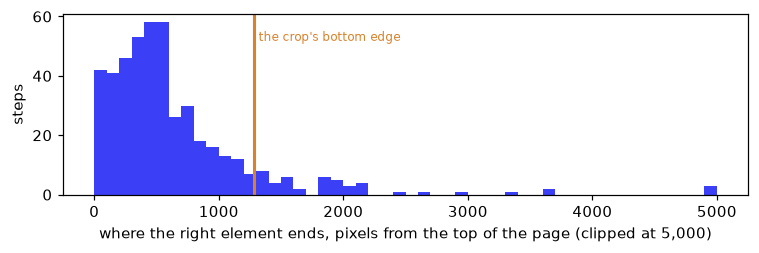

In [ ]:
steps = pd.DataFrame([{"split": s, "height": r["page"]["height"], "gold_bottom": r["page"]["gold_bottom"]} for s, rs in (("train", train), ("test", test)) for r in rs])
print(steps.groupby("split").height.describe(percentiles=[0.5, 0.9])[["min", "50%", "90%", "max"]].round(0))
print(f"the right element ends inside the top 1,280 pixels on {np.mean(steps.gold_bottom <= 1280):.0%} of the steps")
fig, ax = plt.subplots(figsize=(7, 2.4))
ax.hist(steps.gold_bottom.clip(upper=5000), bins=np.arange(0, 5100, 100), color="#3b3ff5")
ax.axvline(1280, color="#d9822b", lw=2); ax.text(1320, ax.get_ylim()[1] * 0.85, "the crop's bottom edge", color="#d9822b", fontsize=8)
ax.set(xlabel="where the right element ends, pixels from the top of the page (clipped at 5,000)", ylabel="steps"); plt.tight_layout(); plt.show()

Nine steps in ten have the element inside the crop, most of them within the first 700 pixels, although half the test pages are taller than 3,800 pixels and one in ten taller than 9,600. A single square at the top keeps nearly every answer, and keeps the text legible: 1,280 pixels shrunk to 1,024 is 80% of the original size. In sysone, the crop is a box on the `Image` transform, `Image(side=1024, box=(0, 0, 1280, 1280))`. A screenshot smaller than the box passes through whole, so a model trained this way reads an agent's viewport the same way.

## How long a row gets

Each question is one row: the image's tokens, then the question with its options, then the page's text. The converter's questions are long. Each carries laya-browser's rules for choosing an action, about 300 tokens of text that are the same for every step, and a target question lists 45 elements. So the question part needs up to about 1,500 tokens. The multimodal presets leave it 384, and to fit 45 options into that, sysone's row builder, following Laya's budget rules, cuts each option to 8 tokens, its index and anchor included. That leaves a few words of each element's label, and the rules get cut to a handful of tokens. Nothing is dropped, but most of what a target row says is gone. All five runs therefore get room for everything: rows of up to 3,072 tokens, 1,536 of them for the question. Every encoder here takes rows that long: NeoMME reads 16,384 positions, ModernVBERT's text tower 7,999, ModernBERT-large 8,192. The row lengths each encoder then gets, on the test steps:

In [ ]:
BOX = (0, 0, 1280, 1280)
BUDGET = dict(max_len=3072, head_max_len=1536)
text_only = lambda rs: [dict(r, state={k: v for k, v in r["state"].items() if k != "image"}) for r in rs]
RUNS = {"NeoMME-260M, screenshot": (multimodal_app, "Hcompany/NeoMME-260M", True),
        "ModernVBERT, screenshot": (multimodal_app, "ModernVBERT/modernvbert", True),
        "NeoMME-260M, text only": (multimodal_app, "Hcompany/NeoMME-260M", False),
        "ModernVBERT, text only": (multimodal_app, "ModernVBERT/modernvbert", False),
        "ModernBERT-large, text only": (text_app, "answerdotai/ModernBERT-large", False)}

def make_data(shot):
    "The pilot's steps, with or without the screenshot, and the transforms of the screens notebook: the crop, and URLs masked"
    return TypedDecisions(train if shot else text_only(train), valid=test if shot else text_only(test),
                          tfms=([Image(side=1024, box=BOX)] if shot else []) + WEB_TFMS)

lengths = {}
for name, (app, encoder, shot) in RUNS.items():
    spec = EncoderSpec.from_pretrained(encoder)
    if shot and spec.processor is not None: prepare_processor(spec.processor, 1024)
    data = make_data(shot); data.bind(spec.processor or spec.tokenizer, spec.template.replace(**BUDGET))
    n = [row.n_tokens for r in test for row in data.builder.build_record(apply_tfms(data.tfms, r), train=False, skip_errors=True)]
    lengths[name] = {"rows": len(n), "median tokens": int(np.median(n)), "longest": max(n), "dropped": data.builder.stats["dropped"]}
    del spec, data; release()
pd.DataFrame(lengths).T

,rows,median tokens,longest,dropped
"NeoMME-260M, screenshot",382,1923,3049,0
"ModernVBERT, screenshot",382,1198,2111,0
"NeoMME-260M, text only",382,906,2031,0
"ModernVBERT, text only",382,902,1816,0
"ModernBERT-large, text only",382,902,1816,0


Nothing is dropped. NeoMME's screenshot rows are the longest, a median of 1,923 tokens: at 1,024 pixels its image alone takes 1,058 positions, one per 32-pixel patch plus a marker at the end of each row of patches. ModernVBERT's image at 1,024 pixels is four 512-pixel tiles and the global view, 5 × 64 = 320 image tokens and a few markers, so its screenshot rows are about 300 tokens longer than its text-only ones.

## Five heads

Each run is its application with that application's defaults, the budgets above, and the same head recipe: `fit_one_cycle(10, lr=1e-3)` on the 276 training steps, in batches of 4 rows. Ten passes over 552 rows is about as many steps as the other tutorials' heads take. At 1,024 pixels each ModernVBERT row carries five images, so the application encodes one row at a time. It used to shrink the training batch to one row as well, although a head that trains from cached anchors never runs the vision tower. This pilot found that, and every head here trains on the same batches (the finding is in the [ModernVBERT](../23_modernvbert.ipynb#a-head-only-run) notebook).

In [ ]:
def answers(learn) -> dict:
    "Every held-out decision's predicted option and gold, from the cached anchors"
    p, ds = learn.get_preds("valid"), learn.dataset("valid")
    return {(c, q): (int(i), int(l)) for c, q, i, l in zip(ds["case"], ds["qid"], p["logits"].argmax(-1), p["labels"])}

preds, cost = {}, {}
for name, (app, encoder, shot) in RUNS.items():
    spec = EncoderSpec.from_pretrained(encoder)
    kw = {"image_side": 1024} if shot and app is multimodal_app else {}
    t = time.time()
    torch.manual_seed(0)                                     # the same starting head in every run, and on every run of the notebook
    learn = quiet(app.decision_learner(make_data(shot), spec, template=spec.template.replace(**BUDGET), cache_dir=work / "features", **kw))
    n = len(learn.dataset("train")) + len(learn.dataset("valid"))           # every row through the encoder once, into the cache
    t_encode = time.time() - t
    learn.fit_one_cycle(10, lr=1e-3)
    preds[name] = answers(learn)
    cost[name] = {"seconds per row to encode": t_encode / n, "minutes to encode": t_encode / 60, "seconds to train": time.time() - t - t_encode}
    print(f"{name}: {n} rows encoded in {t_encode / 60:.1f} min · {memory_line()}")
    del learn, spec; release()

NeoMME-260M, screenshot: 934 rows encoded in 9.0 min · peak memory 3.1 GB · MPS 1.1 GB
ModernVBERT, screenshot: 934 rows encoded in 9.5 min · peak memory 3.1 GB · MPS 1.4 GB
NeoMME-260M, text only: 934 rows encoded in 3.6 min · peak memory 3.1 GB · MPS 1.1 GB
ModernVBERT, text only: 934 rows encoded in 2.1 min · peak memory 3.1 GB · MPS 1.4 GB
ModernBERT-large, text only: 934 rows encoded in 4.9 min · peak memory 3.1 GB · MPS 2.0 GB


## Results

Accuracy on each question on the 191 test steps, and on both at once (a step is right when its operation and its target are). The first row is what always answering the commonest operation, and picking one of 45 elements at random, would get.

In [ ]:
gold_bottom = {r["id"]: r["page"]["gold_bottom"] for r in test}
def summary(p) -> dict:
    op = {c: pr == g for (c, q), (pr, g) in p.items() if q == "operation"}
    tg = {c: pr == g for (c, q), (pr, g) in p.items() if q != "operation"}
    inside = [tg[c] for c in tg if gold_bottom[c] <= 1280]; outside = [tg[c] for c in tg if gold_bottom[c] > 1280]
    return {"operation": np.mean(list(op.values())), "target": np.mean(list(tg.values())),
            "both": np.mean([op[c] and tg[c] for c in tg]), "target, element in the crop": np.mean(inside),
            "target, element below it": np.mean(outside)}

commonest = Counter(r["gold"]["operation"]["label"] for r in train).most_common(1)[0][0]
guess = {"operation": np.mean([r["gold"]["operation"]["label"] == commonest for r in test]), "target": np.mean([1 / len(r["questions"][next(k for k in r["questions"] if k != "operation")]["criteria"]) for r in test])}
table = pd.DataFrame({"guessing": guess} | {name: summary(p) for name, p in preds.items()}).T
print(f"{sum(gold_bottom[r['id']] <= 1280 for r in test)} test steps have the element in the crop, {sum(gold_bottom[r['id']] > 1280 for r in test)} below it")
table.style.format("{:.3f}", na_rep="")

167 test steps have the element in the crop, 24 below it


,operation,target,both,"target, element in the crop","target, element below it"
guessing,0.801,0.117,,,
"NeoMME-260M, screenshot",0.812,0.136,0.105,0.144,0.083
"ModernVBERT, screenshot",0.885,0.209,0.136,0.210,0.208
"NeoMME-260M, text only",0.880,0.173,0.147,0.174,0.167
"ModernVBERT, text only",0.869,0.199,0.141,0.198,0.208
"ModernBERT-large, text only",0.843,0.194,0.141,0.198,0.167


- **No head learned to pick the element.** With 276 training steps, every run's target accuracy stays within ten points of guessing (0.117): from 0.136 to 0.209. On 191 steps, one standard error is about 0.03, so the pilot can't rank the encoders on this question with any confidence. The [text tutorial](06_web_text.ipynb)'s heads, trained on 2,000 steps with 12 candidates each, reach about 0.40, so a 45-way choice needs many more examples than a pilot has.
- **The operation question does move.** Answering CLICK every time gets 0.801. ModernVBERT with the screenshot gets 0.885, NeoMME without it 0.880, ModernVBERT without it 0.869, and ModernBERT-large 0.843. NeoMME with the screenshot gets 0.812, barely above always answering CLICK. These steps offer the actions their candidate elements allow, though, and that alone gives the operation away on most of them: on the first 300 `test_website` steps, the rule *the rarest action offered* gets 0.797 against 0.783 for always clicking (the [screens notebook](../21_screens.ipynb#one-step-one-record)'s finding), so part of these gains may be that rule, which the pilot didn't measure.
- **The screenshot didn't help.** ModernVBERT gains about a point on each question with it, within the noise. NeoMME loses with it: 0.812 against 0.880 on the operation, and 0.136 against 0.173 on the target. At this scale the page's text carries what the heads can learn, and NeoMME's thousand image tokens get in the way.
- **Below the crop.** Only 24 test steps have their element below the crop, too few to say much. ModernVBERT with the screenshot scores the same on them as on the rest (0.208 and 0.210), and NeoMME lower (0.083 and 0.144).

In [ ]:
pd.DataFrame(cost).T.round(2)

,seconds per row to encode,minutes to encode,seconds to train
"NeoMME-260M, screenshot",0.58,9.00,19.40
"ModernVBERT, screenshot",0.61,9.48,32.11
"NeoMME-260M, text only",0.23,3.62,16.75
"ModernVBERT, text only",0.13,2.08,18.61
"ModernBERT-large, text only",0.32,4.91,17.49


The screenshot is what costs. At 1,024 pixels, both image encoders take about 0.6 seconds a row, against 0.13 for ModernVBERT reading text alone, 0.23 for NeoMME and 0.32 for ModernBERT-large. ModernVBERT's image takes fewer tokens than NeoMME's, 320 against 1,058, but its vision tower encodes five images for every row. Training takes seconds either way, since the heads read the cache.

## What this means for the default

Three comparisons now bear on which encoder the multimodal application should use by default, each with the same records and recipe for both encoders:

| | NeoMME-260M | ModernVBERT |
| --- | --- | --- |
| 100 MNIST digits, a 10-way choice ([comparison tutorial](03_neomme_vs_modernvbert.ipynb)) | 0.31 | 0.84 |
| 80 photos, a hot-dog noul (the same tutorial) | 0.74 | 0.94 |
| Web pages as text: the 12-way element choice on the test and `ood` websites ([text tutorial](06_web_text.ipynb)) | 0.406 and 0.446 | 0.384 and 0.446 |
| Web pages with the screenshot, a pilot: the operation question ([screens tutorial](07_web_screens.ipynb)) | 0.812 | 0.885 |
| The same pilot: the element to act on | 0.136 | 0.209 |
| Seconds to encode a screenshot row at 1,024 pixels | 0.58 | 0.61 |

ModernVBERT wins every comparison that uses an image. On text the two are level: NeoMME is two points ahead on the test websites, and they're even on the `ood` ones. NeoMME was built for pages and screenshots, so this pilot was the comparison that could have turned the small-image results around, and it didn't: with its screenshot, NeoMME's heads did worse than with the page's text alone. The evidence points to ModernVBERT as the better default, and on it the default moved to ModernVBERT on 2026-09-30 (the [NeoMME notebook](../20_neomme.ipynb#which-encoder-by-default)). The pilot is small, though, and its element question stayed near chance for every encoder, so the full run below could still revise that.

## What a full run needs

A run that could settle the element question, and the default with it, would use all of both splits: the 7,775 training steps (81 row groups, 7.6 GB) and the 1,019 `test_website` steps (12 row groups, 1.1 GB).

- **Download and disk.** At the pilot's pace, about half a minute per row group, streaming takes under an hour. The screenshots take about 10 GB once saved, and the anchor caches about 1.3 GB per run: long target rows with 45 anchors, in float32.
- **Encoding.** At 0.6 seconds a row and two rows a step, each image encoder needs about three hours on this laptop for the screenshot runs. The text-only runs need between 40 minutes and 1.6 hours each. That is a job for a cloud GPU, or for a night.
- **One more run.** NeoMME's template has a variant that puts the page before the question, `neomme_page_first`. Since NeoMME did worse with its screenshot than without it, a full run should try the page first too, in case the order of the row is what held it back.

In [ ]:
print(f"the whole notebook: {(time.time() - t_start) / 60:.1f} minutes · {memory_line()}")

the whole notebook: 31.9 minutes · peak memory 3.1 GB · MPS 0.0 GB
